In [13]:
# Setup and Imports
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.append("..")

from plots.wandb_utils import get_wandb_stats

# Configure matplotlib for publication quality
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 11
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.2

In [14]:
# Benchmark / run configuration
# Set to ["tpch"] (default) or ["tpch", "ceb"] for a combined plot.
selected_benchmarks = ["tpch", "ceb"]

# Run IDs to load for each benchmark.
run_ids = {
    "tpch": "h1mv9o9r",
    "ceb": "5qumtphx",
}

benchmark_defaults = {
    "tpch": {"num_queries": 22, "target_sf": 20, "label": "TPC-H"},
    "ceb": {"num_queries": 16, "target_sf": 2, "label": "CEB"},
}

if not selected_benchmarks:
    raise ValueError("selected_benchmarks is empty.")

for benchmark_name in selected_benchmarks:
    if benchmark_name not in benchmark_defaults:
        raise ValueError(
            f"Unsupported benchmark in selected_benchmarks: {benchmark_name}"
        )
    if benchmark_name not in run_ids:
        raise ValueError(f"Missing run id for benchmark '{benchmark_name}'")

# Load all selected runs
loaded_runs = {}
for benchmark_name in selected_benchmarks:
    run_id = run_ids[benchmark_name]
    if run_id.startswith("<replace"):
        raise ValueError(
            f"Please set run_ids['{benchmark_name}'] before running this notebook."
        )

    summary, history, config = get_wandb_stats(
        run_id,
        skip_cache=True,
        wandb_run_cache_path=Path("/mnt/labstore/bespoke_olap/wandb_cache"),
    )

    num_queries = benchmark_defaults[benchmark_name]["num_queries"]
    target_sf = benchmark_defaults[benchmark_name]["target_sf"]

    filtered_hist = history[history["validation/scale_factor"] == target_sf]
    filtered_hist = filtered_hist[filtered_hist["validation/trace_mode"] == False]
    filtered_hist = filtered_hist[
        filtered_hist["validation/num_queries"] == num_queries
    ]

    if filtered_hist.empty:
        print(
            f"Warning: No data for benchmark={benchmark_name}, scale factor={target_sf}"
        )

    loaded_runs[benchmark_name] = {
        "run_id": run_id,
        "summary": summary,
        "history": history,
        "filtered_hist": filtered_hist,
        "config": config,
        "num_queries": num_queries,
        "target_sf": target_sf,
        "label": benchmark_defaults[benchmark_name]["label"],
    }

    ts = (
        filtered_hist.iloc[-1].get("_timestamp", "N/A")
        if not filtered_hist.empty
        else "N/A"
    )
    print(f"Using {benchmark_name} run {run_id} at scale factor {target_sf}")
    print(f"Timestamp: {ts}")

✗ Error loading W&B data: Could not find run <Run learneddb/bespoke-olap-agents/h1mv9o9r (not found)>


CommError: Could not find run <Run learneddb/bespoke-olap-agents/h1mv9o9r (not found)>

In [ ]:
# Extract per-query metrics for each selected benchmark
benchmark_metrics = {}

for benchmark_name in selected_benchmarks:
    run_data = loaded_runs[benchmark_name]
    summary = run_data["summary"]
    filtered_hist = run_data["filtered_hist"]

    regex = r"validation/query_([0-9a-zA-Z]+)/speedup"
    query_ids = sorted(
        {
            match.group(1)
            for elem in summary.keys()
            for match in [re.match(regex, elem)]
            if match
        }
    )

    print(f"[{benchmark_name}] Found {len(query_ids)} queries")

    speedups = {}
    duckdb_runtimes = {}
    bespoke_runtimes = {}

    for query_id in query_ids:
        if query_id in ["08a", "8a"]:
            # 8a is outlier: duckdb produces sometimes crazy high runtime (in the hundreds of seconds)
            # though amazing speedups for bespoke, this is not really representative of the overall performance, so we skip it for now
            continue

        speedup_key = f"validation/query_{query_id}/speedup"
        duckdb_key = f"validation/query_{query_id}/duckdb_runtime_ms"

        valid_rows = filtered_hist[
            filtered_hist[speedup_key].notna() & filtered_hist[duckdb_key].notna()
        ]

        if valid_rows.empty:
            continue

        last_row = valid_rows.iloc[-1]
        speedup = float(last_row[speedup_key])
        duckdb_rt = float(last_row[duckdb_key]) / 1000.0  # ms -> s
        bespoke_rt = duckdb_rt / speedup if speedup > 0 else duckdb_rt

        if not np.isfinite(speedup):
            bespoke_rt = 0.001  # set to 1ms
            speedup = bespoke_rt / duckdb_rt

        # if not np.isfinite(speedup) or speedup <= 0:
        #     print(
        #         f"Warning: Invalid speedup for {benchmark_name} query {query_id} (speedup={speedup}), skipping..."
        #     )
        #     continue

        speedups[query_id] = speedup
        duckdb_runtimes[query_id] = duckdb_rt
        bespoke_runtimes[query_id] = bespoke_rt

    finite_speedups = [v for v in speedups.values() if np.isfinite(v)]
    total_duckdb_time = sum(duckdb_runtimes.values())
    total_bespoke_time = sum(bespoke_runtimes.values())

    overall_speedup_median = np.median(finite_speedups) if finite_speedups else np.nan
    overall_speedup_mean = np.mean(finite_speedups) if finite_speedups else np.nan
    overall_speedup_total = (
        total_duckdb_time / total_bespoke_time if total_bespoke_time > 0 else np.nan
    )

    benchmark_metrics[benchmark_name] = {
        "query_ids": query_ids,
        "speedups": speedups,
        "duckdb_runtimes": duckdb_runtimes,
        "bespoke_runtimes": bespoke_runtimes,
        "overall_speedup_median": overall_speedup_median,
        "overall_speedup_mean": overall_speedup_mean,
        "total_duckdb_time": total_duckdb_time,
        "total_bespoke_time": total_bespoke_time,
        "overall_speedup_total": overall_speedup_total,
        "label": loaded_runs[benchmark_name]["label"],
    }

    print(f"\n[{benchmark_name}] Performance Summary:")
    print(f"  Median speedup: {overall_speedup_median:.2f}x")
    print(f"  Mean speedup: {overall_speedup_mean:.2f}x")
    print(f"  Total time (DuckDB): {total_duckdb_time:.2f}s")
    print(f"  Total time (Bespoke): {total_bespoke_time:.2f}s")
    print(f"  Overall speedup (total time): {overall_speedup_total:.2f}x")

# Backward-compatible aliases for cells that expect single-benchmark variables
is_single_benchmark = len(selected_benchmarks) == 1
if is_single_benchmark:
    active_benchmark = selected_benchmarks[0]
    metrics = benchmark_metrics[active_benchmark]

    query_ids = metrics["query_ids"]
    speedups = metrics["speedups"]
    duckdb_runtimes = metrics["duckdb_runtimes"]
    bespoke_runtimes = metrics["bespoke_runtimes"]
    overall_speedup_median = metrics["overall_speedup_median"]
    overall_speedup_mean = metrics["overall_speedup_mean"]
    total_duckdb_time = metrics["total_duckdb_time"]
    total_bespoke_time = metrics["total_bespoke_time"]
    overall_speedup_total = metrics["overall_speedup_total"]

[tpch] Found 22 queries

[tpch] Performance Summary:
  Median speedup: 16.40x
  Mean speedup: 23.67x
  Total time (DuckDB): 54.35s
  Total time (Bespoke): 4.62s
  Overall speedup (total time): 11.78x
[ceb] Found 16 queries

[ceb] Performance Summary:
  Median speedup: 4.66x
  Mean speedup: 6.79x
  Total time (DuckDB): 22.12s
  Total time (Bespoke): 2.27s
  Overall speedup (total time): 9.74x


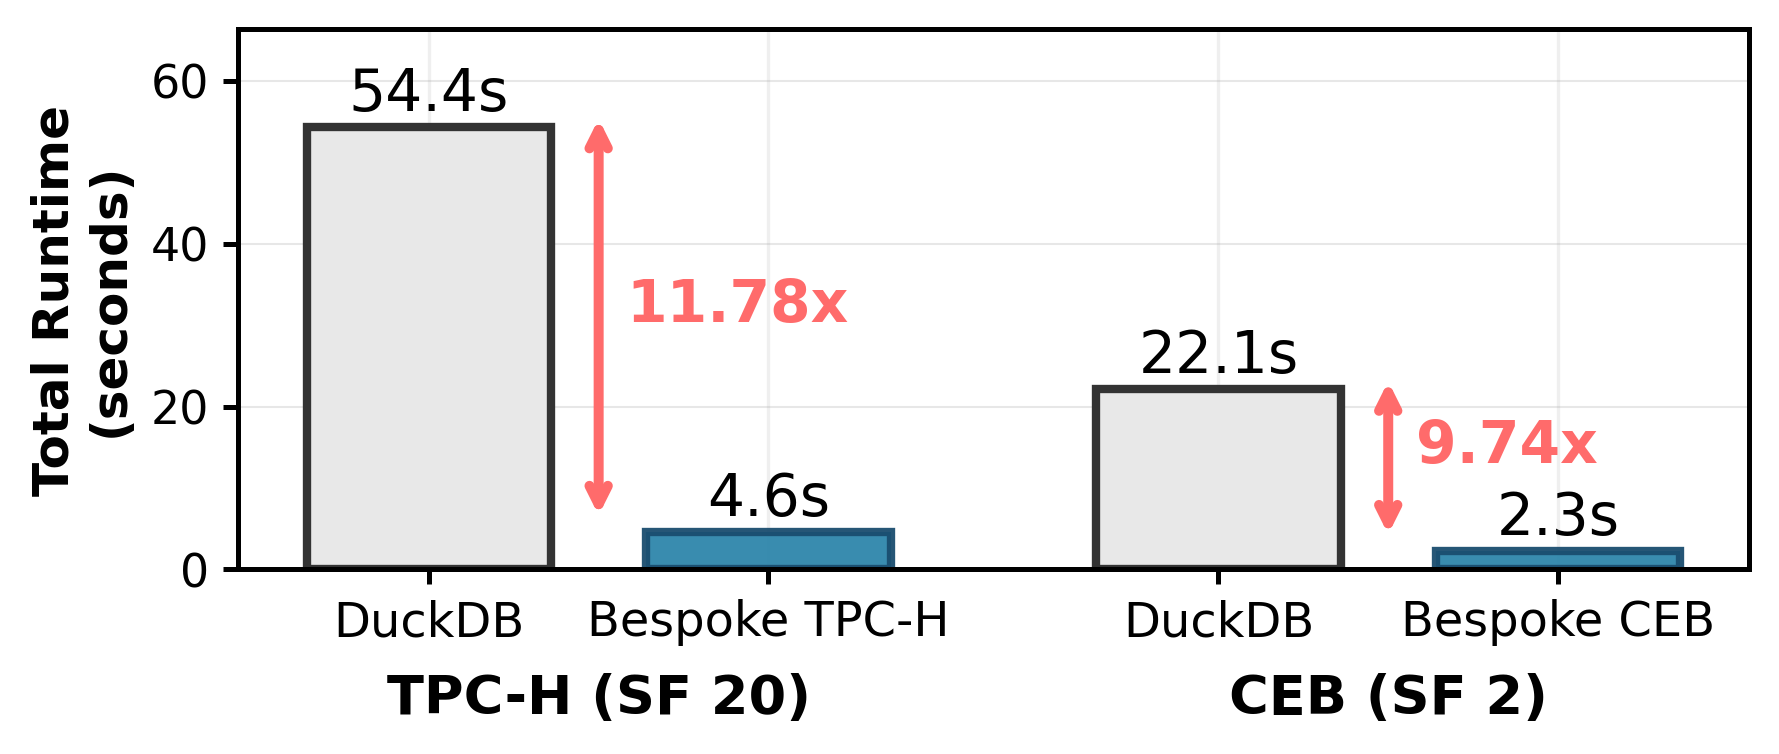


✓ Plot saved as 'journal_speedup_combined_tpch_ceb.pdf'


In [ ]:
if is_single_benchmark:
    # Original two-bar plot for one benchmark
    fig, ax_main = plt.subplots(figsize=(5, 3))

    systems = ["DuckDB", f"Bespoke {benchmark_metrics[active_benchmark]['label']}"]
    runtimes = [total_duckdb_time, total_bespoke_time]

    x_pos = np.arange(len(systems))
    bar1 = ax_main.bar(
        x_pos[0],
        runtimes[0],
        width=0.6,
        color="#E8E8E8",
        edgecolor="#333333",
        linewidth=2.0,
        alpha=1.0,
    )
    bar2 = ax_main.bar(
        x_pos[1],
        runtimes[1],
        width=0.6,
        color="#2E86AB",
        edgecolor="#1a4d6f",
        linewidth=2.0,
        alpha=0.95,
    )

    bars = list(bar1) + list(bar2)

    def annotate_bar(ax, bar, fmt="%.1f", fontsize=12, fontweight="bold"):
        height = bar.get_height()
        x_mid = bar.get_x() + bar.get_width() / 2
        ax.text(
            x_mid,
            height + max(runtimes) * 0.02,
            f"{fmt % height}s",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            fontweight=fontweight,
        )

    for bar in bars:
        annotate_bar(ax_main, bar)

    mid_y = (total_duckdb_time + total_bespoke_time) / 2
    ax_main.annotate(
        "",
        xy=(0.5, total_bespoke_time),
        xytext=(0.5, total_duckdb_time),
        arrowprops=dict(arrowstyle="<->", color="#FF6B6B", lw=2.5),
    )
    ax_main.text(
        0.55,
        mid_y,
        f"{overall_speedup_total:.2f}x Speedup",
        fontsize=13,
        fontweight="bold",
        color="#FF6B6B",
        va="center",
    )

    ax_main.set_ylabel("Total Runtime (seconds)", fontsize=12, fontweight="bold")
    ax_main.set_xticks(x_pos)
    ax_main.set_xticklabels(systems, fontsize=12, fontweight="bold")
    ax_main.set_ylim(0, max(runtimes) * 1.15)
    ax_main.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
    ax_main.set_axisbelow(True)
    ax_main.spines["top"].set_visible(False)
    ax_main.spines["right"].set_visible(False)

    plt.savefig(
        "figures/journal_speedup.pdf", dpi=300, bbox_inches="tight", facecolor="white"
    )

    print("Avg. Speedup: %.2fx" % overall_speedup_mean)
    print("Median Speedup: %.2fx" % overall_speedup_median)

    plt.show()
    print("\n✓ Plot saved as 'journal_speedup.pdf'")

else:
    # Combined grouped plot for multiple benchmarks (e.g., TPC-H + CEB)
    fig, ax_main = plt.subplots(figsize=(6.5, 3))

    benchmark_order = selected_benchmarks
    benchmark_labels = [benchmark_metrics[b]["label"] for b in benchmark_order]
    duckdb_vals = np.array(
        [benchmark_metrics[b]["total_duckdb_time"] for b in benchmark_order]
    )
    bespoke_vals = np.array(
        [benchmark_metrics[b]["total_bespoke_time"] for b in benchmark_order]
    )

    # Per-group and per-bar spacing control
    group_gap = 2.0
    bar_width = 0.62
    bar_offset = 0.43

    group_centers = np.arange(len(benchmark_order)) * group_gap
    duck_x = group_centers - bar_offset
    bespoke_x = group_centers + bar_offset

    bars_duck = ax_main.bar(
        duck_x,
        duckdb_vals,
        width=bar_width,
        color="#E8E8E8",
        edgecolor="#333333",
        linewidth=2.0,
        alpha=1.0,
    )
    bars_bespoke = ax_main.bar(
        bespoke_x,
        bespoke_vals,
        width=bar_width,
        color="#2E86AB",
        edgecolor="#1a4d6f",
        linewidth=2.0,
        alpha=0.95,
    )

    y_max = max(np.max(duckdb_vals), np.max(bespoke_vals))

    # Tick at each bar
    xtick_positions = []
    xtick_labels = []
    for i, benchmark_name in enumerate(benchmark_order):
        benchmark_label = benchmark_metrics[benchmark_name]["label"]
        xtick_positions.extend([duck_x[i], bespoke_x[i]])
        xtick_labels.extend(["DuckDB", f"Bespoke {benchmark_label}"])

    ax_main.set_xticks(xtick_positions)
    ax_main.set_xticklabels(
        xtick_labels,
        fontsize=11.5,
        # fontweight="bold",
    )

    # Group labels below each benchmark pair
    for i, benchmark_label in enumerate(benchmark_labels):
        ax_main.text(
            group_centers[i],
            -0.19,
            f"{benchmark_label} (SF {benchmark_defaults[benchmark_order[i]]['target_sf']})",
            transform=ax_main.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=13,
            fontweight="bold",
        )

    # Speedup arrows per benchmark pair
    for i, benchmark_name in enumerate(benchmark_order):
        duck_h = duckdb_vals[i]
        bespoke_h = bespoke_vals[i]
        speedup_total = benchmark_metrics[benchmark_name]["overall_speedup_total"]

        ax_main.annotate(
            "",
            xy=(group_centers[i], bespoke_h + 1),
            xytext=(group_centers[i], duck_h + 2),
            arrowprops=dict(arrowstyle="<->", color="#FF6B6B", lw=2.4),
        )
        ax_main.text(
            group_centers[i] + 0.07,
            (duck_h + bespoke_h) / 2 + 3,
            f"{speedup_total:.2f}x",
            ha="left",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="#FF6B6B",
        )

    for bars in (bars_duck, bars_bespoke):
        for bar in bars:
            h = bar.get_height()
            ax_main.text(
                bar.get_x() + bar.get_width() / 2,
                h + y_max * 0.01,
                f"{h:.1f}s",
                ha="center",
                va="bottom",
                fontsize=14,
            )

    ax_main.set_ylabel("Total Runtime\n(seconds)", fontsize=12, fontweight="bold")
    ax_main.set_ylim(0, y_max * 1.22)
    ax_main.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
    ax_main.set_axisbelow(True)

    plt.subplots_adjust(bottom=0.28)
    plt.savefig(
        "figures/journal_speedup_combined_tpch_ceb.pdf",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()
    print("\n✓ Plot saved as 'journal_speedup_combined_tpch_ceb.pdf'")

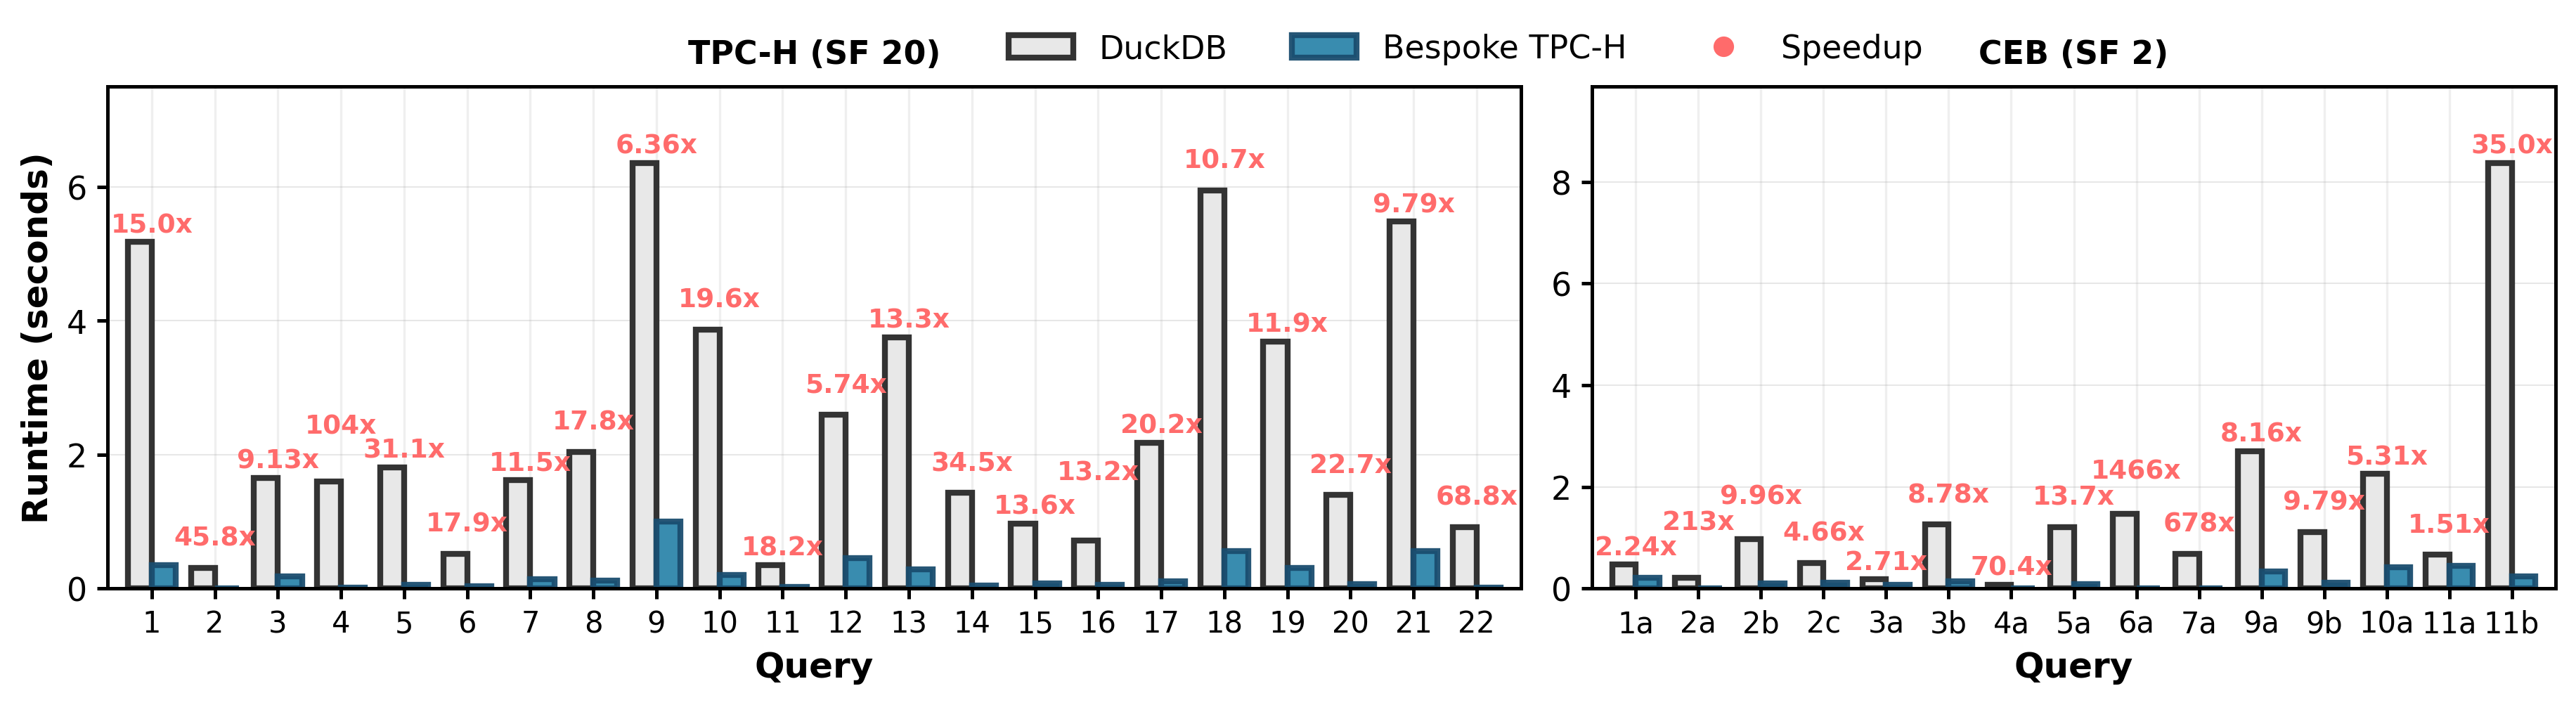


✓ Combined per-query subplot figure saved as 'journal_per_query_absolute_runtime_combined.pdf'


In [41]:
# When True (and multiple benchmarks are selected), per-query runtimes are shown
# in a single figure using one subplot per benchmark in a single row.
combine_per_query_subplots = True


# Per-query absolute runtime plot (DuckDB vs Bespoke)
# Can render either:
# - one figure per benchmark (original behavior), or
# - one combined figure with horizontal subplots (single row)
from matplotlib.lines import Line2D


def _query_sort_key(qid: str):
    return (0, int(qid)) if qid.isdigit() else (1, qid)


def _annotate_speedups_without_overlap(
    ax, x_positions, pair_tops, duck_vals, bespoke_vals
):
    top_ref = float(np.max(pair_tops)) if len(pair_tops) else 1.0
    if top_ref <= 0:
        top_ref = 1.0

    base_offset = top_ref * 0.01
    min_vertical_gap = top_ref * 0.03
    max_label_y = 0.0

    prev_x = None
    prev_y = None
    prev_lane = 0
    placed_bboxes = []
    renderer = ax.figure.canvas.get_renderer()

    for i in range(len(x_positions)):
        speedup = duck_vals[i] / bespoke_vals[i] if bespoke_vals[i] > 0 else np.nan
        if not np.isfinite(speedup):
            continue

        if speedup > 100:
            speedup_text = f"{speedup:.0f}x"
        elif speedup > 10:
            speedup_text = f"{speedup:.1f}x"
        else:
            speedup_text = f"{speedup:.2f}x"
        base_y = float(pair_tops[i]) + base_offset
        lane = 0
        if prev_x is not None and abs(float(x_positions[i]) - prev_x) <= 1.05:
            lane = 1 - prev_lane

        y = base_y + lane * min_vertical_gap
        if prev_x is not None and abs(float(x_positions[i]) - prev_x) <= 1.05:
            if abs(y - prev_y) < min_vertical_gap:
                y += min_vertical_gap

        label_fontsize = 9  # 7 if len(speedup_text) >= 7 else 8

        text_obj = ax.text(
            x_positions[i],  # + x_shift,
            y,
            speedup_text,
            ha="center",
            va="bottom",
            fontsize=label_fontsize,
            fontweight="bold",
            color="#FF6B6B",
        )

        ax.figure.canvas.draw()
        text_bbox = text_obj.get_window_extent(renderer=renderer).expanded(1.03, 1.12)
        nudge_attempts = 0
        while any(text_bbox.overlaps(prev_bbox) for prev_bbox in placed_bboxes):
            nudge_attempts += 1
            if nudge_attempts > 12:
                break
            y += min_vertical_gap
            text_obj.set_y(y)
            ax.figure.canvas.draw()
            text_bbox = text_obj.get_window_extent(renderer=renderer).expanded(
                1.03, 1.12
            )

        placed_bboxes.append(text_bbox)

        prev_x = float(x_positions[i])
        prev_y = y
        prev_lane = lane
        max_label_y = max(max_label_y, y)

    return max_label_y


# Collect plottable data once so both modes can use it
plot_payload = []
for benchmark_name in selected_benchmarks:
    metrics = benchmark_metrics[benchmark_name]
    benchmark_label = metrics["label"]

    query_ids_local = metrics["query_ids"]
    duckdb_runtimes_local = metrics["duckdb_runtimes"]
    bespoke_runtimes_local = metrics["bespoke_runtimes"]

    plot_query_ids = [
        qid
        for qid in query_ids_local
        if qid in duckdb_runtimes_local and qid in bespoke_runtimes_local
    ]

    if not plot_query_ids:
        print(
            f"Skipping per-query plot for {benchmark_label}: no per-query runtime data available."
        )
        continue

    plot_query_ids = sorted(plot_query_ids, key=_query_sort_key)

    labels = [qid.lstrip("0") for qid in plot_query_ids]
    labels = [f"{qid}" for qid in labels]

    duck_vals = np.array([duckdb_runtimes_local[qid] for qid in plot_query_ids])
    bespoke_vals = np.array([bespoke_runtimes_local[qid] for qid in plot_query_ids])

    plot_payload.append(
        {
            "benchmark_name": benchmark_name,
            "benchmark_label": benchmark_label,
            "plot_query_ids": plot_query_ids,
            "labels": labels,
            "duck_vals": duck_vals,
            "bespoke_vals": bespoke_vals,
        }
    )


if not plot_payload:
    print("No per-query runtime data available for plotting.")

elif combine_per_query_subplots and len(plot_payload) > 1:
    # Single-row subplots with width proportional to number of queries shown
    query_counts = [len(p["plot_query_ids"]) for p in plot_payload]
    width_ratios = query_counts

    # Per-query width budget + fixed margins per subplot
    per_query_width = 0.34
    fixed_width_per_subplot = 1.2
    fig_width = sum(q * per_query_width + fixed_width_per_subplot for q in query_counts)
    fig_height = 3.5

    fig, axes = plt.subplots(
        1,
        len(plot_payload),
        figsize=(fig_width, fig_height),
        gridspec_kw={"width_ratios": width_ratios},
    )

    if len(plot_payload) == 1:
        axes = [axes]

    speedup_legend_handle = Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        color="#FF6B6B",
        markersize=6,
        label="Speedup",
    )

    for idx, (ax, payload) in enumerate(zip(axes, plot_payload)):
        benchmark_name = payload["benchmark_name"]
        benchmark_label = payload["benchmark_label"]
        labels = payload["labels"]
        duck_vals = payload["duck_vals"]
        bespoke_vals = payload["bespoke_vals"]

        x = np.arange(len(labels))
        width = 0.38

        ax.bar(
            x - width / 2,
            duck_vals,
            width=width,
            color="#E8E8E8",
            edgecolor="#333333",
            linewidth=2.0,
            alpha=1.0,
            label="DuckDB",
        )
        ax.bar(
            x + width / 2,
            bespoke_vals,
            width=width,
            color="#2E86AB",
            edgecolor="#1a4d6f",
            linewidth=2.0,
            alpha=0.95,
            label=f"Bespoke {benchmark_label}",
        )

        pair_tops = np.maximum(duck_vals, bespoke_vals)
        max_label_y = _annotate_speedups_without_overlap(
            ax, x, pair_tops, duck_vals, bespoke_vals
        )

        ax.set_xlim(-0.7, len(labels) - 0.3)
        if idx == 0:
            ax.set_ylabel("Runtime (seconds)", fontsize=12, fontweight="bold")
        ax.set_xlabel("Query", fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)
        top_ref = float(pair_tops.max()) if len(pair_tops) else 1.0
        if top_ref <= 0:
            top_ref = 1.0
        ax.set_ylim(0, max(top_ref * 1.18, max_label_y + top_ref * 0.08))
        ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)

        sf = benchmark_defaults[benchmark_name]["target_sf"]
        ax.set_title(
            f"{benchmark_label} (SF {sf})", fontsize=11, fontweight="bold", pad=8
        )

    handles, legend_labels = axes[0].get_legend_handles_labels()
    handles.append(speedup_legend_handle)
    legend_labels.append("Speedup")
    fig.legend(
        handles,
        legend_labels,
        frameon=False,
        fontsize=11,
        loc="lower center",
        ncols=3,
        bbox_to_anchor=(0.555, 0.87),
    )

    fig.subplots_adjust(wspace=0.06, bottom=0.2)

    out_name = "journal_per_query_absolute_runtime_combined.pdf"
    out_path = f"figures/{out_name}"

    plt.savefig(
        out_path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.005,
        facecolor="white",
    )

    plt.show()
    print(f"\n✓ Combined per-query subplot figure saved as '{out_name}'")

else:
    # Original behavior: one figure per benchmark
    for payload in plot_payload:
        benchmark_name = payload["benchmark_name"]
        benchmark_label = payload["benchmark_label"]
        plot_query_ids = payload["plot_query_ids"]
        labels = payload["labels"]
        duck_vals = payload["duck_vals"]
        bespoke_vals = payload["bespoke_vals"]

        fig, ax = plt.subplots(figsize=(9, 3))

        x = np.arange(len(plot_query_ids))
        width = 0.38

        ax.bar(
            x - width / 2,
            duck_vals,
            width=width,
            color="#E8E8E8",
            edgecolor="#333333",
            linewidth=2.0,
            alpha=1.0,
            label="DuckDB",
        )

        ax.bar(
            x + width / 2,
            bespoke_vals,
            width=width,
            color="#2E86AB",
            edgecolor="#1a4d6f",
            linewidth=2.0,
            alpha=0.95,
            label=f"Bespoke {benchmark_label}",
        )

        pair_tops = np.maximum(duck_vals, bespoke_vals)
        max_label_y = _annotate_speedups_without_overlap(
            ax, x, pair_tops, duck_vals, bespoke_vals
        )

        ax.set_xlim(-0.7, len(plot_query_ids) - 0.3)

        ax.set_ylabel("Runtime (seconds)", fontsize=12, fontweight="bold")
        ax.set_xlabel("Query", fontsize=11, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        top_ref = float(pair_tops.max()) if len(pair_tops) else 1.0
        if top_ref <= 0:
            top_ref = 1.0
        ax.set_ylim(0, max(top_ref * 1.18, max_label_y + top_ref * 0.08))
        ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)

        sf = benchmark_defaults[benchmark_name]["target_sf"]
        ax.set_title(
            f"{benchmark_label} (SF {sf})", fontsize=10, fontweight="bold", pad=8
        )

        speedup_legend_handle = Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            color="#FF6B6B",
            markersize=6,
            label="Speedup",
        )
        handles, legend_labels = ax.get_legend_handles_labels()
        handles.append(speedup_legend_handle)
        legend_labels.append("Speedup")
        ax.legend(
            handles,
            legend_labels,
            frameon=False,
            fontsize=10,
            loc="upper right",
            ncols=3,
            bbox_to_anchor=(0.68, -0.08),
        )

        fig.subplots_adjust(left=0, right=1, top=1, bottom=0.24)

        out_name = (
            f"journal_per_query_absolute_runtime_{benchmark_name}.pdf"
            if len(selected_benchmarks) > 1
            else "journal_per_query_absolute_runtime.pdf"
        )
        out_path = f"figures/{out_name}"

        plt.savefig(
            out_path,
            dpi=300,
            bbox_inches="tight",
            pad_inches=0,
            facecolor="white",
        )

        plt.show()
        print(f"\n✓ [{benchmark_label}] Plot saved as '{out_name}'")